# Replicate: Nvidia AI IOT NanoSAM
### .onnx (onnxruntime-gpu)
July 29th

NanoSAM is a Segment Anything (SAM) model variant that is capable of running in 🔥 real-time 🔥 on NVIDIA Jetson Orin Platforms with NVIDIA TensorRT.

In [ ]:
# ------------------------------------------------------------ #
#                 Clean environment setup
# ------------------------------------------------------------ #

"""
# clean env wipe & activate
conda env remove --name nanosam_arm64 -y
conda deactivate
conda create -n nanosam_arm64 python=3.10 -y
conda activate nanosam_arm64

sudo apt update
sudo apt install libcudnn8 libcudnn8-dev
conda install -c conda-forge libstdcxx-ng=12 -y

"""

In [ ]:
# ------------------------------------------------------------ #
#        Installation of nanosam_arm64 repo requirements
# ------------------------------------------------------------ #

"""
git clone https://github.com/NVIDIA-AI-IOT/nanosam
cd nanosam
python3 setup.py develop --user


# More requirements
pip install timm==1.0.17 ultralytics==8.0.120 matplotlib==3.5.3 'opencv-python<4.9' jetson-stats


# Typical np version mismatch
pip uninstall -y numpy
pip install "numpy>=1.19.2,<2.0"
# pip install numpy==1.26.4 

# Now install the CUDA PyTorch 2.5.0a0 (compatible with jp61 torch)
pip install --no-cache https://developer.download.nvidia.com/compute/redist/jp/v61/pytorch/torch-2.5.0a0+872d972e41.nv24.08.17622132-cp310-cp310-linux_aarch64.whl

# download torchvision 0.20.0a0 (compatible with jp61 torch)
cd ~/vision/
python3 setup.py install
cd ~

# --- ONNXRUNTIME-GPU (build from scratch) ------------- #

cd ~/onnxruntime
pip uninstall onnxruntime -y
pip install build/Linux/Release/dist/onnxruntime_gpu-*.whl --force-reinstall
pip install sympy==1.13.1 numpy==1.26.4

"""

# Debug Support

# Check your conda env GLIBCXX versions
# strings /home/copter/miniconda3/envs/nanosam_arm64/lib/python3.10/site-packages/zmq/backend/cython/../../../../.././libstdc++.so.6 | grep GLIBCXX

# trt2torch is apparently an issue and is obsolete for trt --version=10.3.0 
# additionally `pip install pycuda`

In [1]:
# from nanosam.utils.predictor import Predictor
import onnxruntime as ort


In [ ]:
# check in CLI: 
# pip install https://github.com/ultralytics/assets/releases/download/v0.0.0/onnxruntime_gpu-1.20.0-cp310-cp310-linux_aarch64.whl
# python -c "import onnxruntime; print(onnxruntime.__version__)"

# Check ___cuDNN Version___
# dpkg -l | grep cudnn


In [2]:
import onnx
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import cv2
import os
import torch
import tensorrt     # import even if not used


In [3]:
# Verify versions

print(f"ONNX version: {onnx.__version__}")
print(f"NumPy version: {np.__version__}")       # shold be 1.26.4 or else causes mem core dump issues
print(f"TensorRT version: {tensorrt.__version__}")
print("Available ONNX Runtime providers: ", ort.get_available_providers())

ONNX version: 1.13.1
NumPy version: 1.26.4
TensorRT version: 10.3.0
Available ONNX Runtime providers:  ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [4]:
# 🧹 Clear the PyTorch CUDA cache
torch.cuda.empty_cache()

import gc
gc.collect()

0

Audit the onnx sessions

In [5]:
import psutil
from collections import defaultdict

print('check globals: ', globals().items())

# ============================================================================
# CHECK FOR EXISTING ONNX SESSIONS IN CURRENT KERNEL
# ============================================================================
def list_onnx_sessions():
    """Find all ONNX InferenceSession objects in current namespace"""
    sessions = {}
    
    # Check global variables
    for name, obj in globals().items():
        if isinstance(obj, ort.InferenceSession):
            try:
                providers = obj.get_providers()
                inputs = [inp.name for inp in obj.get_inputs()]
                outputs = [out.name for out in obj.get_outputs()]
                sessions[name] = {
                    'object': obj,
                    'providers': providers,
                    'inputs': inputs,
                    'outputs': outputs
                }
            except:
                sessions[name] = {'object': obj, 'status': 'invalid/corrupted'}
    
    # Check garbage collector for unreferenced sessions
    unreferenced_sessions = []
    for obj in gc.get_objects():
        if isinstance(obj, ort.InferenceSession):
            # Check if this session is not in our named sessions
            if obj not in [s.get('object') for s in sessions.values()]:
                try:
                    providers = obj.get_providers()
                    unreferenced_sessions.append({
                        'id': id(obj),
                        'providers': providers,
                        'status': 'unreferenced'
                    })
                except:
                    unreferenced_sessions.append({
                        'id': id(obj),
                        'status': 'unreferenced/corrupted'
                    })
    
    return sessions, unreferenced_sessions

# Example usage
list_onnx_sessions()

check globals:  dict_items([('__name__', '__main__'), ('__doc__', 'Automatically created module for IPython interactive environment'), ('__package__', None), ('__loader__', None), ('__spec__', None), ('__builtin__', <module 'builtins' (built-in)>), ('__builtins__', <module 'builtins' (built-in)>), ('_ih', ['', '# from nanosam.utils.predictor import Predictor\nimport onnxruntime as ort', 'import onnx\nimport numpy as np\nfrom PIL import Image, ImageDraw\nimport matplotlib.pyplot as plt\nimport cv2\nimport os\nimport torch\nimport tensorrt     # import even if not used', '# Verify versions\n\nprint(f"ONNX version: {onnx.__version__}")\nprint(f"NumPy version: {np.__version__}")       # shold be 1.26.4 or else causes mem core dump issues\nprint(f"TensorRT version: {tensorrt.__version__}")\nprint("Available ONNX Runtime providers: ", ort.get_available_providers())', '# 🧹 Clear the PyTorch CUDA cache\ntorch.cuda.empty_cache()\n\nimport gc\ngc.collect()', 'import psutil\nfrom collections impo

({}, [])

In [ ]:
def cleanup_all_onnx_sessions():
    """Clean up ALL ONNX sessions (named and unreferenced)"""
    sessions, unreferenced = list_onnx_sessions()
    
    # Clean up named sessions
    for name in list(sessions.keys()):
        try:
            if name in globals():
                del globals()[name]
                print(f"Deleted session: {name}")
        except Exception as e:
            print(f"Error deleting {name}: {e}")
    
    # Force garbage collection to clean unreferenced sessions
    collected = gc.collect()
    print(f"Garbage collected {collected} objects")
    
    # Clear CUDA cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print("CUDA cache cleared")

cleanup_all_onnx_sessions()

In [ ]:
# # Image path (used for olf image processing)

# # Load the image
# # image = PIL.open("/home/copter/jetson_benchmark/images/dogs.jpg")
# image_path = "/home/copter/jetson_benchmark/images/dogs.jpg"
# img = Image.open(image_path).convert("RGB")
# img = img.resize((1024, 1024), resample=Image.BILINEAR)
# w, h = img.size  # now both are 1024

# # Display the image
# plt.figure(figsize=(10, 8))
# plt.imshow(img)
# plt.axis('on')  # Hide axes for cleaner display
# plt.title("Dogs Image")
# plt.show()

In [6]:
# Video processing

# video path (use for frame processing)
video_path = "/home/copter/Data/Aerial view of manhattan.mp4"

# Create a VideoCapture object
cap = cv2.VideoCapture(video_path)

# Check if video was opened successfully
if not cap.isOpened():
    print("Error: Could not open video file.")
    exit()

# Get video properties (frame width, height, and FPS)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# Define the codec and create a VideoWriter object to save the output
fourcc = cv2.VideoWriter_fourcc(*'mp4v') # You can change the codec
out = cv2.VideoWriter('/home/copter/Data/output_nyc_video.mp4', fourcc, fps, (frame_width, frame_height))

In [7]:
encoder_model_path="/home/copter/onnx_models/nvidia_ai_iot_resnet18_image_encoder.onnx"
decoder_model_path="/home/copter/onnx_models/nvidia_ai_iot_mobile_sam_mask_decoder.onnx"

# ---- Use optimized versions ----------------------

# encoder_model_path=""
# decoder_model_path=""

In [8]:
# Prevent TensorRT plugin conflicts
os.environ['ORT_DISABLE_TRT_PLUGINS'] = '1'

# Clear existing CUDA memory and cleanup
torch.cuda.empty_cache()
gc.collect()

# Cleanup any existing sessions
if 'enc_sess' in globals():
    del enc_sess
if 'dec_sess' in globals():
    del dec_sess

# Configure robust execution providers
print("--- Checking Available Execution Providers ---")
available_providers = ort.get_available_providers() 

# # NOTE: normally woudl include but, its giving issues [TensorrtExecutionProvider]
# providers = [
#     ('CUDAExecutionProvider', {
#         'device_id': 0,
#         'arena_extend_strategy': 'kNextPowerOfTwo',
#         'gpu_mem_limit': 8 * 1024 * 1024 * 1024,  # 8GB limit
#         'enable_cuda_graph': False,
#     }),
#     'CPUExecutionProvider'
# ]

providers = [
    'CUDAExecutionProvider',
    'CPUExecutionProvider'
]

# Configure session options
session_options = ort.SessionOptions()
session_options.intra_op_num_threads = 6
session_options.inter_op_num_threads = 1
session_options.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL
# session_options.enable_mem_pattern = False
# session_options.enable_cpu_mem_arena = False

# Create sessions with error handling
try:
    enc_sess = ort.InferenceSession(encoder_model_path, sess_options=session_options, providers=providers)
    dec_sess = ort.InferenceSession(decoder_model_path, sess_options=session_options, providers=providers)

    # Verify which provider was actually chosen by ONNX Runtime
    if 'TensorrtExecutionProvider' in enc_sess.get_providers() and 'TensorrtExecutionProvider' in dec_sess.get_providers():
        print("🚀 ONNX models successfully loaded and are using TensorrtExecutionProvider.")
    elif 'CUDAExecutionProvider' in enc_sess.get_providers() and 'CUDAExecutionProvider' in dec_sess.get_providers():
        print("✅ ONNX models successfully loaded and are using CUDAExecutionProvider fallback (TensorRT not available or failed).")
    else:
        print("⚠️ ONNX models loaded successfully with CPUExecutionProvider (neither TensorRT nor CUDA available or failed).")
        print(f"Encoder session fallback: see providers... {enc_sess.get_providers()}")
        print(f"Decoder session fallback: see providers... {dec_sess.get_providers()}")

except Exception as e:
    print(f"❌ GPU session creation failed: {e}")
    print("🔄 Falling back to CPU-only providers...")
    
    try:
        # Fallback to CPU only
        cpu_providers = ['CPUExecutionProvider']
        enc_sess = ort.InferenceSession(encoder_model_path, sess_options=session_options, providers=cpu_providers)
        dec_sess = ort.InferenceSession(decoder_model_path, sess_options=session_options, providers=cpu_providers)
        print("✅ CPU fallback successful")
    except Exception as cpu_e:
        print(f"❌ CPU fallback also failed: {cpu_e}")
        raise RuntimeError("Failed to load ONNX models with any provider")

# Force cleanup function for end of processing
def cleanup_onnx_sessions():
    global enc_sess, dec_sess
    try:
        if 'enc_sess' in globals(): del enc_sess
        if 'dec_sess' in globals(): del dec_sess
    except: pass
    gc.collect()
    torch.cuda.empty_cache()
    print("ONNX sessions cleaned up")

print("ONNX sessions ready. Call cleanup_onnx_sessions() when done.")

--- Checking Available Execution Providers ---
✅ ONNX models successfully loaded and are using CUDAExecutionProvider fallback (TensorRT not available or failed).
ONNX sessions ready. Call cleanup_onnx_sessions() when done.


In [ ]:
# List the objects that are created
list_onnx_sessions()

# --- Resource allocation --------------
def check_gpu_memory():
    """Check GPU memory usage"""
    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            memory_allocated = torch.cuda.memory_allocated(i) / 1024**3  # GB
            memory_reserved = torch.cuda.memory_reserved(i) / 1024**3    # GB
            memory_total = torch.cuda.get_device_properties(i).total_memory / 1024**3
            print(f"GPU {i}: {memory_allocated:.2f}GB allocated, {memory_reserved:.2f}GB reserved, {memory_total:.2f}GB total")
    else:
        print("CUDA not available")

def check_cpu_memory():
    """Check CPU memory usage"""
    memory = psutil.virtual_memory()
    process = psutil.Process()
    process_memory = process.memory_info().rss / 1024**3  # GB
    
    print(f"System RAM: {memory.used/1024**3:.2f}GB used / {memory.total/1024**3:.2f}GB total ({memory.percent:.1f}%)")
    print(f"Current process: {process_memory:.2f}GB")

def check_onnx_provider_status(enc_sess=None, dec_sess=None):
    """Check available ONNX Runtime providers and their status"""

    if enc_sess and enc_sess != None:
        print("Available Encoder ONNX Runtime providers:", enc_sess.get_providers())
        print("Available Decoder ONNX Runtime providers:", dec_sess.get_providers())
    else:
        available = ort.get_available_providers()
        print("Available ONNX Runtime providers:", available)

    
    # Check if TensorRT is causing issues
    import os
    trt_disabled = os.environ.get('ORT_DISABLE_TRT_PLUGINS', 'Not Set')
    print(f"ORT_DISABLE_TRT_PLUGINS: {trt_disabled}")


check_cpu_memory()
check_onnx_provider_status(enc_sess, dec_sess)

In [9]:
# Everything model grid helper function

def segment_everything_with_grid(frame, enc_sess, dec_sess, grid_size=32, score_threshold=0.8):
    """
    Segment everything by sampling points on a grid
    """
    # Convert the video frame to a PIL Image
    img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    
    # Resize the image and run the encoder
    img = img.resize((1024, 1024), resample=Image.BILINEAR)
    img_arr = np.array(img).astype(np.float32) / 255.0
    input_image = img_arr.transpose(2, 0, 1)[None, :, :, :]
    
    # Run the SAM encoder
    enc_input_name = enc_sess.get_inputs()[0].name
    image_embeddings = enc_sess.run(None, {enc_input_name: input_image})[0]

    # Get decoder input names
    dec_input_names = [inp.name for inp in dec_sess.get_inputs()]
    
    h, w = img.size[1], img.size[0]  # PIL image dimensions
    
    # Create grid of points (default it the full screen)
    x_coords = np.linspace(0, w-1, grid_size)
    y_coords = np.linspace(0, h-1, grid_size)
    
    all_masks = []
    all_scores = []
    
    # Sample points on grid (skip some to avoid too many)
    for x in x_coords[::4]:  
        for y in y_coords[::4]:
            # Create point prompt
            point_coords = np.array([[[x, y]]], dtype=np.float32)
            point_labels = np.array([[1]], dtype=np.float32)
            
            # Dummy inputs
            dummy_mask_input = np.zeros((1, 1, 256, 256), dtype=np.float32)
            dummy_has_mask_input = np.zeros((1,), dtype=np.float32)
            
            # Prepare decoder inputs
            dec_inputs = {
                dec_input_names[0]: image_embeddings,
                dec_input_names[1]: point_coords,
                dec_input_names[2]: point_labels,
                dec_input_names[3]: dummy_mask_input,
                dec_input_names[4]: dummy_has_mask_input,
            }
            
            # Run decoder
            scores, mask_out = dec_sess.run(None, dec_inputs)
            
            # Take best mask (highest score)
            best_idx = np.argmax(scores[0])
            if scores[0, best_idx] > score_threshold:  # Quality threshold
                all_masks.append(mask_out[0, best_idx])
                all_scores.append(scores[0, best_idx])
    
    return all_masks, all_scores

# # Usage:
# all_masks, all_scores = segment_everything_with_grid(img, enc_sess, dec_sess, image_embeddings)
# print(f"Found {len(all_masks)} masks")

# # 3) Print shapes & count
# print("all_masks shape:", all_masks.shape)   # should be (1, N, H, W)
# print("mask_out (single mask) shape:", all_masks[0].shape)   # should be (1, N, H, W)
# print("all_scores   shape:", all_scores.shape)     # should be (1, N)
# n_masks = all_masks.shape[1]
# print("number of masks predicted:", n_masks)

### Video processing (single frame)

In [ ]:
# Single Frame Processing

# Read the first frame
ret, frame = cap.read()

# Check if frame was read successfully
if ret:
    # Convert the frame to a PIL Image
    img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    
    # Resize the image and run the encoder
    img = img.resize((1024, 1024), resample=Image.BILINEAR)
    img_arr = np.array(img).astype(np.float32) / 255.0
    input_image = img_arr.transpose(2, 0, 1)[None, :, :, :]
    
    # Run the SAM encoder
    enc_input_name = enc_sess.get_inputs()[0].name
    image_embeddings = enc_sess.run(None, {enc_input_name: input_image})[0]

    # Display the first frame
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("First Frame")
    plt.axis('off')
    plt.show()
    

# Release the video objects
cap.release()

Everything mode returned 64 masks


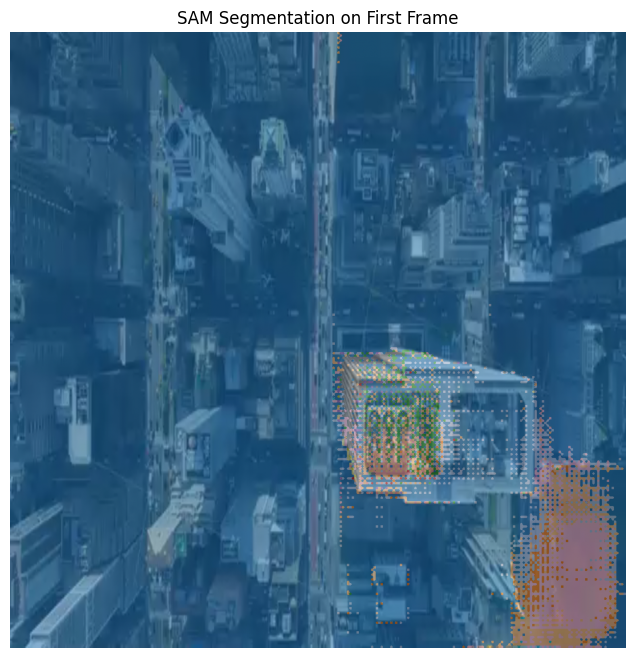

In [12]:
# Run the "everything mode" segmentation
score_threshold = 0.8
all_masks, all_scores = segment_everything_with_grid(frame, enc_sess, dec_sess, score_threshold=score_threshold)
print(f"Everything mode returned {len(all_masks)} masks")

# Create the blended mask
img_array = np.array(img)
h, w = img_array.shape[:2]
segment_map = np.zeros((h, w), dtype=np.int32)
segment_id = 1

for mask, score in zip(all_masks, all_scores):
    if score < score_threshold:
        continue
    binary_mask = mask > 0
    if binary_mask.shape != (h, w):
        mask_pil = Image.fromarray((binary_mask * 255).astype(np.uint8))
        mask_pil = mask_pil.resize((w, h))
        binary_mask = np.array(mask_pil) > 128
    segment_map[binary_mask & (segment_map == 0)] = segment_id
    segment_id += 1
    
# Create and display the blended result using Matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(img_array)
plt.imshow(segment_map, cmap='tab20', alpha=0.5)
plt.title("SAM Segmentation on First Frame")
plt.axis('off')
plt.show()

### Video processing (full video)

In [ ]:
# # Full Video processing loop -------------

# while cap.isOpened():
#     ret, frame = cap.read()
#     if not ret:
#         break # Break the loop if the video has ended
        
#     # --- YOUR EXISTING LOGIC GOES HERE ---
#     # Convert the frame to a PIL Image for your existing code
#     img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    
#     # Resize the image and run the encoder
#     img = img.resize((1024, 1024), resample=Image.BILINEAR)
#     img_arr = np.array(img).astype(np.float32) / 255.0
#     input_image = img_arr.transpose(2, 0, 1)[None, :, :, :]
    
#     # Run the SAM encoder
#     enc_input_name = enc_sess.get_inputs()[0].name
#     image_embeddings = enc_sess.run(None, {enc_input_name: input_image})[0]
    
#     # Run the "everything mode" segmentation
#     all_masks, all_scores = segment_everything_with_grid(img, enc_sess, dec_sess, image_embeddings)
    
#     # Create and apply the blended mask
#     img_array = np.array(img)
#     h, w = img_array.shape[:2]
#     segment_map = np.zeros((h, w), dtype=np.int32)
#     score_threshold = 0.8
#     segment_id = 1
    
#     for mask, score in zip(all_masks, all_scores):
#         if score < score_threshold:
#             continue
#         binary_mask = mask > 0
#         if binary_mask.shape != (h, w):
#             mask_pil = Image.fromarray((binary_mask * 255).astype(np.uint8))
#             mask_pil = mask_pil.resize((w, h))
#             binary_mask = np.array(mask_pil) > 128
#         segment_map[binary_mask & (segment_map == 0)] = segment_id
#         segment_id += 1
        
#     # Create the blended frame (adjusting to OpenCV's BGR color space)
#     colored_segments = plt.cm.tab20(segment_map / segment_map.max())[:,:,:3]
#     blended_frame = img_array * 0.7 + colored_segments * 255 * 0.3
#     blended_frame = cv2.cvtColor(blended_frame.astype(np.uint8), cv2.COLOR_RGB2BGR)
    
#     # Write the processed frame to the output video file
#     out.write(blended_frame)
    
#     # Optional: Display the frame as it's being processed
#     cv2.imshow('Processed Video', blended_frame)
#     if cv2.waitKey(1) & 0xFF == ord('q'):
#         break

# # Release the video objects and close all windows
# cap.release()
# out.release()
# cv2.destroyAllWindows()